In [1]:
import math, json, time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "figure.facecolor": "#08090e", "axes.facecolor":   "#0d0f18",
    "axes.edgecolor":   "#1c1f2e", "axes.labelcolor":  "#d4d4d4",
    "text.color":       "#d4d4d4", "xtick.color":      "#4a4d62",
    "ytick.color":      "#4a4d62", "grid.color":       "#1c1f2e",
    "grid.linewidth":   0.5,       "lines.linewidth":  1.8,
    "font.family":      "monospace","font.size":        10,
})
ORANGE="#e8a020"; BLUE="#6ab0f5"; GREEN="#4ade80"; RED="#f87171"
CYAN="#67e8f9";   PURPLE="#a78bfa"; GOLD="#fbbf24"; MUTED="#4a4d62"

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"torch {torch.__version__}  |  device: {device}")

# ── building blocks ───────────────────────────────────────────────────────────
class FnLeaf(nn.Module):
    def __init__(self): super().__init__(); self.lin = nn.Linear(1, 1)
    def forward(self, x): return self.lin(x).squeeze(-1)
    def formula(self, _=None):
        w, b = self.lin.weight.item(), self.lin.bias.item()
        return f"({w:.4g}*x+{b:.4g})"

class EMLNode(nn.Module):
    def __init__(self, left, right): super().__init__(); self.left=left; self.right=right
    def forward(self, x=None):
        return torch.exp(self.left(x)) - torch.log(F.softplus(self.right(x)))
    def formula(self, _=None):
        return f"eml({self.left.formula()},{self.right.formula()})"

def build(s):
    if s == 'L': return FnLeaf()
    return EMLNode(build(s[1]), build(s[2]))

def _depth(s): return 0 if s=='L' else 1+max(_depth(s[1]),_depth(s[2]))
def _leaves(s): return 1 if s=='L' else _leaves(s[1])+_leaves(s[2])
def _balance(s):
    if s=='L': return 0
    return max(abs(_depth(s[1])-_depth(s[2])), _balance(s[1]), _balance(s[2]))

print("Building blocks ready.")


torch 2.11.0+cpu  |  device: cpu
Building blocks ready.


In [2]:
# ── Candidate topologies for deep search ─────────────────────────────────────
# Source:
#   exp_04 sin winner:  eml(1,eml(eml(1,eml(1,1)),1))           MSE=7.76e-4
#   exp_06 cos winner:  eml(eml(1,eml(1,1)),eml(eml(1,1),1))    MSE=8.77e-4
#   exp_06 sin winner:  eml(eml(1,eml(1,1)),eml(1,eml(1,1)))    MSE=1.99e-3
#   exp_06 sin rank 2:  eml(1,eml(1,eml(eml(1,1),1)))           MSE=2.86e-3

# Shape notation: ('N', left, right) = eml(left, right), 'L' = leaf
CANDIDATES = {
    'A_e04_sin': ('N', 'L', ('N', ('N', 'L', ('N', 'L', 'L')), 'L')),
    # eml(1, eml(eml(1,eml(1,1)), 1))   balance=3  depth=4

    'B_e06_cos': ('N', ('N', 'L', ('N', 'L', 'L')), ('N', ('N', 'L', 'L'), 'L')),
    # eml(eml(1,eml(1,1)), eml(eml(1,1),1))   balance=1  depth=3

    'C_e06_sin': ('N', ('N', 'L', ('N', 'L', 'L')), ('N', 'L', ('N', 'L', 'L'))),
    # eml(eml(1,eml(1,1)), eml(1,eml(1,1)))   balance=1  depth=3

    'D_e06_s2':  ('N', 'L', ('N', 'L', ('N', ('N', 'L', 'L'), 'L'))),
    # eml(1, eml(1,eml(eml(1,1),1)))   balance=2  depth=4
}

print(f"{'Name':<15} {'Desc':<48} {'D':<4} {'L':<4} {'Bal'}")
print('─' * 80)
for name, s in CANDIDATES.items():
    from functools import reduce
    def _desc(s):
        if s=='L': return '1'
        return f"eml({_desc(s[1])},{_desc(s[2])})"
    print(f"{name:<15} {_desc(s):<48} {_depth(s):<4} {_leaves(s):<4} {_balance(s)}")

# targets
x_grid = torch.linspace(0, 2*math.pi, 100)
x_in   = x_grid.unsqueeze(1)
sin_target = torch.sin(x_grid)
cos_target = torch.cos(x_grid)

PREV_BEST = {'sin': 7.76e-4, 'cos': 8.77e-4}
print(f"\nPrev best sin: {PREV_BEST['sin']:.4e}  (exp_04)")
print(f"Prev best cos: {PREV_BEST['cos']:.4e}  (exp_06)")


Name            Desc                                             D    L    Bal
────────────────────────────────────────────────────────────────────────────────
A_e04_sin       eml(1,eml(eml(1,eml(1,1)),1))                    4    5    3
B_e06_cos       eml(eml(1,eml(1,1)),eml(eml(1,1),1))             3    6    1
C_e06_sin       eml(eml(1,eml(1,1)),eml(1,eml(1,1)))             3    6    1
D_e06_s2        eml(1,eml(1,eml(eml(1,1),1)))                    4    5    3

Prev best sin: 7.7600e-04  (exp_04)
Prev best cos: 8.7700e-04  (exp_06)


In [3]:
# ── Deep search: 20 restarts, LR sweep ──────────────────────────────────────

def deep_search(shape, y_target, target_name,
                lam=5e-5, num_restarts=20, steps=1000,
                lrs=(0.01, 0.005, 0.002)):
    # Try multiple learning rates; keep the single best model overall.
    best_loss, best_model = float('inf'), None
    all_losses = []

    for lr in lrs:
        for r in range(num_restarts):
            torch.manual_seed(r * 1009 + hash(target_name) % 997)
            model = build(shape)
            # Perturb initialisation: stronger scatter for higher restart index
            with torch.no_grad():
                for p in model.parameters():
                    p.add_(torch.randn_like(p) * (0.1 + 0.05 * r))
            opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0)
            last = float('inf')
            for step in range(steps):
                opt.zero_grad()
                try:
                    pred = model(x_in)
                    raw  = F.mse_loss(pred, y_target)
                    if not torch.isfinite(raw): break
                    l1   = lam * sum(p.abs().sum()
                                     for nm, p in model.named_parameters()
                                     if 'weight' in nm)
                    (raw + l1).backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    opt.step()
                    last = raw.item()
                except Exception: break
            all_losses.append(last)
            if last < best_loss:
                best_loss, best_model = last, model

    return dict(
        loss    = best_loss,
        formula = best_model.formula() if best_model else 'N/A',
        _model  = best_model,
        all_losses = all_losses,
    )

print("deep_search() ready.")
print(f"  20 restarts x 3 LRs (0.01, 0.005, 0.002) x 1000 steps per shape")
print(f"  = 60 trials per shape per target")


deep_search() ready.
  20 restarts x 3 LRs (0.01, 0.005, 0.002) x 1000 steps per shape
  = 60 trials per shape per target


In [4]:
# ── Run deep search on all candidates x both targets ─────────────────────────

def _desc(s):
    if s=='L': return '1'
    return f"eml({_desc(s[1])},{_desc(s[2])})"

results = {}  # {target_name: {shape_name: record}}
t_start = time.time()

for target_name, y_target in [('sin', sin_target), ('cos', cos_target)]:
    results[target_name] = {}
    for shape_name, shape in CANDIDATES.items():
        t0 = time.time()
        rec = deep_search(shape, y_target, target_name)
        elapsed = time.time() - t0
        results[target_name][shape_name] = rec
        beat = '★ BEAT' if rec['loss'] < PREV_BEST[target_name] else ''
        print(f"{target_name}  {shape_name:<15}  MSE={rec['loss']:.4e}  ({elapsed:.0f}s)  {beat}")

total_elapsed = time.time() - t_start
print(f"\nTotal time: {total_elapsed:.0f}s")


sin  A_e04_sin        MSE=9.6498e-04  (122s)  


sin  B_e06_cos        MSE=3.2143e-04  (115s)  ★ BEAT


sin  C_e06_sin        MSE=3.8781e-04  (134s)  ★ BEAT


sin  D_e06_s2         MSE=1.0378e-03  (80s)  


cos  A_e04_sin        MSE=1.9124e-04  (76s)  ★ BEAT


cos  B_e06_cos        MSE=1.2099e-03  (60s)  


cos  C_e06_sin        MSE=9.5874e-04  (87s)  


cos  D_e06_s2         MSE=2.9096e-02  (100s)  

Total time: 775s


In [5]:
# ── Rank and summarise ────────────────────────────────────────────────────────

for target_name in ('sin', 'cos'):
    ranked = sorted(results[target_name].items(), key=lambda kv: kv[1]['loss'])
    prev   = PREV_BEST[target_name]
    print(f"\n{'='*70}")
    print(f"{target_name}(x)  |  prev best: {prev:.4e}")
    print(f"{'='*70}")
    print(f"{'Rank':<6} {'Name':<15} {'MSE':<14} {'Beat?':<8} {'Trials':<8} {'Formula[:55]'}")
    print(f"{'─'*70}")
    for rank, (name, rec) in enumerate(ranked, 1):
        beat = '★' if rec['loss'] < prev else ' '
        n_trials = len(rec['all_losses'])
        print(f"{rank:<6} {name:<15} {rec['loss']:<14.4e} {beat:<8} {n_trials:<8} {rec['formula'][:55]}")
    best_name, best_rec = ranked[0]
    # restart spread
    finite = [x for x in best_rec['all_losses'] if x < 10]
    if finite:
        spread = max(finite) - min(finite)
        print(f"\n  Best topology: {best_name}")
        print(f"  Loss spread across {len(finite)}/{len(best_rec['all_losses'])} finite trials: {spread:.4e}")
        print(f"  Min={min(finite):.4e}  Median={sorted(finite)[len(finite)//2]:.4e}  Max={max(finite):.4e}")



sin(x)  |  prev best: 7.7600e-04
Rank   Name            MSE            Beat?    Trials   Formula[:55]
──────────────────────────────────────────────────────────────────────
1      B_e06_cos       3.2143e-04     ★        60       eml(eml((-0.9451*x+1.207),eml((-0.4707*x+2.952),(1.352*
2      C_e06_sin       3.8781e-04     ★        60       eml(eml((-0.8307*x+-0.5425),eml((0.642*x+-1.393),(2.286
3      A_e04_sin       9.6498e-04              60       eml((-0.7682*x+-0.7027),eml(eml((-0.1113*x+1.327),eml((
4      D_e06_s2        1.0378e-03              60       eml((0.558*x+-2.081),eml((0.6887*x+0.008565),eml(eml((0

  Best topology: B_e06_cos
  Loss spread across 42/60 finite trials: 1.1460e-01
  Min=3.2143e-04  Median=1.8699e-02  Max=1.1492e-01

cos(x)  |  prev best: 8.7700e-04
Rank   Name            MSE            Beat?    Trials   Formula[:55]
──────────────────────────────────────────────────────────────────────
1      A_e04_sin       1.9124e-04     ★        60       eml((-0.4342*x+

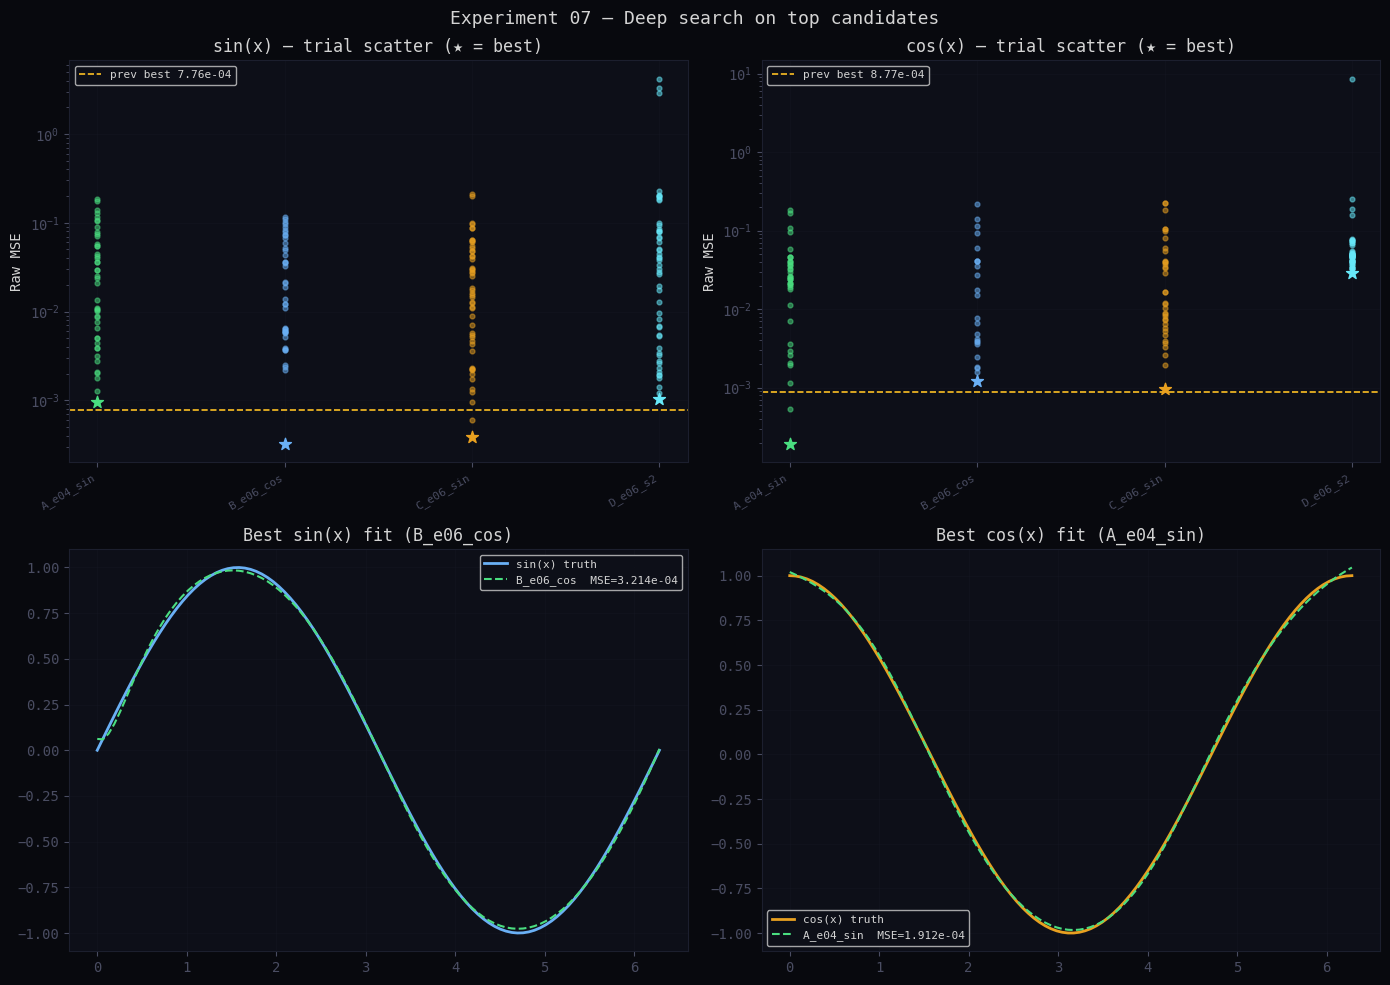

Saved -> D:\monogate\python\notebooks\experiment_07_results.png


In [6]:
# ── 4-panel figure ────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Experiment 07 — Deep search on top candidates', color='#d4d4d4', fontsize=13)

x_np   = x_grid.numpy()
sin_np = sin_target.numpy()
cos_np = cos_target.numpy()

colors = [GREEN, BLUE, ORANGE, CYAN]
bar_colors = {'sin': colors, 'cos': colors}

# Panels A & B: scatter of all trial losses per shape
for col, (target_name, y_np) in enumerate([('sin', sin_np), ('cos', cos_np)]):
    ax = axes[0, col]
    for i, (shape_name, rec) in enumerate(results[target_name].items()):
        finite = [x for x in rec['all_losses'] if x < 10]
        ax.scatter([i]*len(finite), finite,
                   alpha=0.5, s=12, color=colors[i % len(colors)], zorder=3)
        ax.scatter([i], [rec['loss']], marker='*', s=80,
                   color=colors[i % len(colors)], zorder=5)
    ax.axhline(PREV_BEST[target_name], color=GOLD, lw=1.2, ls='--',
               label=f"prev best {PREV_BEST[target_name]:.2e}")
    ax.set_xticks(range(len(CANDIDATES)))
    ax.set_xticklabels(list(CANDIDATES.keys()), rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Raw MSE')
    ax.set_yscale('log')
    ax.set_title(f'{target_name}(x) — trial scatter (★ = best)', color='#d4d4d4')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panels C & D: best fit curve
for col, (target_name, y_np, y_target_t) in enumerate([
        ('sin', sin_np, sin_target), ('cos', cos_np, cos_target)]):
    ax = axes[1, col]
    ranked = sorted(results[target_name].items(), key=lambda kv: kv[1]['loss'])
    best_name, best_rec = ranked[0]
    ax.plot(x_np, y_np, color=BLUE if col==0 else ORANGE, lw=2, label=f'{target_name}(x) truth')
    with torch.no_grad():
        pred_np = best_rec['_model'](x_in).numpy()
    ax.plot(x_np, pred_np, color=GREEN, lw=1.5, ls='--',
            label=f"{best_name}  MSE={best_rec['loss']:.3e}")
    ax.set_title(f'Best {target_name}(x) fit ({best_name})', color='#d4d4d4')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
out_png = Path('experiment_07_results.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {out_png.resolve()}")


In [7]:
# ── JSON export ──────────────────────────────────────────────────────────────

leaderboard = {}
for target_name in ('sin', 'cos'):
    ranked = sorted(results[target_name].items(), key=lambda kv: kv[1]['loss'])
    leaderboard[target_name] = [
        {'rank': i+1, 'name': n, 'mse': rec['loss'],
         'beats_prev': rec['loss'] < PREV_BEST[target_name],
         'formula': rec['formula']}
        for i, (n, rec) in enumerate(ranked)
    ]

out_json = Path('experiment_07_results.json')
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(leaderboard, f, indent=2, ensure_ascii=False)
print(f"Saved -> {out_json.resolve()}")

print()
print("EXPERIMENT 07 — FINAL")
print("="*60)
for target_name in ('sin', 'cos'):
    best = leaderboard[target_name][0]
    prev = PREV_BEST[target_name]
    if best['beats_prev']:
        pct = (prev - best['mse']) / prev * 100
        print(f"  {target_name}: NEW BEST {best['mse']:.4e} (+{pct:.1f}%) via {best['name']}")
    else:
        print(f"  {target_name}: best {best['mse']:.4e} (prev {prev:.4e} still leads) via {best['name']}")


Saved -> D:\monogate\python\notebooks\experiment_07_results.json

EXPERIMENT 07 — FINAL
  sin: NEW BEST 3.2143e-04 (+58.6%) via B_e06_cos
  cos: NEW BEST 1.9124e-04 (+78.2%) via A_e04_sin
